# 🫀 Heart Disease Classification Project

## 📌 Project Overview

This project focuses on building a machine learning model to predict whether a patient is likely to have heart disease based on various medical attributes. Early detection of heart disease can help healthcare professionals take preventive actions and improve patient outcomes.

The dataset contains multiple clinical features such as age, sex, blood pressure, cholesterol level, and maximum heart rate. Using these inputs, we train and evaluate different classification models to determine the most accurate predictor.

---

## 🎯 Objectives

- Perform exploratory data analysis (EDA) to understand feature relationships  
- Preprocess data (handle missing values, scaling, encoding)  
- Train multiple machine learning models  
- Compare model performance using evaluation metrics  
- Predict heart disease for new/unseen patient data  

---

## 📊 Dataset Description

The dataset includes the following types of features:

- Demographic information (age, sex)
- Clinical measurements (resting blood pressure, cholesterol)
- Exercise-related attributes (max heart rate, exercise-induced angina)
- Target variable:
  - `1` → Heart disease present  
  - `0` → No heart disease  

---

## 🔍 Machine Learning Workflow

1. Load and explore dataset  
2. Data cleaning and preprocessing  
3. Feature selection  
4. Model training (Logistic Regression, KNN, Random Forest, etc.)  
5. Model evaluation (Accuracy, Precision, Recall, F1-score)  
6. Final prediction  

---



In [1]:
# Regular EDA and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Models from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split



| Code Component | Purpose |
|---------------|---------|
| `numpy` | Performs numerical computations and array operations. |
| `pandas` | Loads, cleans, and manages structured datasets. |
| `matplotlib.pyplot` | Creates basic plots and visualizations. |
| `seaborn` | Generates advanced statistical graphs for data analysis. |
| `LogisticRegression` | Builds a linear classification model for predicting outcomes. |
| `KNeighborsClassifier` | Classifies data based on nearest neighbors. |
| `RandomForestClassifier` | Uses multiple decision trees to improve prediction accuracy. |
| `train_test_split` | Splits dataset into training and testing sets for evaluation. |
| Overall Workflow | Prepares data, visualizes patterns, trains models, and supports prediction. |


 ## Load data

In [2]:
df = pd.read_csv(r"C:\Users\Asus\Desktop\DataSet\heart-disease.csv")

| Column Name | Description |
|------------|-------------|
| age | Age of the patient |
| sex | Gender (1 = male, 0 = female) |
| cp | Chest pain type |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol level |
| fbs | Fasting blood sugar (>120 mg/dl = 1, else 0) |
| restecg | Resting electrocardiographic results |
| thalach | Maximum heart rate achieved |
| exang | Exercise induced angina (1 = yes, 0 = no) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy |
| thal | Thalassemia status |
| target | Heart disease (1 = present, 0 = absent) |


In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


`df.head()` displays the first five rows of the dataset to quickly understand its structure and sample values.


In [4]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


`df.tail()` displays the last five rows of the dataset to review the ending records and check data consistency.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


### `df.info()`
Displays column names, data types, and non-null values to understand the dataset structure.

In [6]:
# check if there is any missing data
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### `df.isnull().sum()`
Checks each column for missing values to ensure data completeness.

In [7]:
# how many classes are in target variable?
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

### `df['target'].value_counts()`
Counts the number of patients with (`1`) and without (`0`) heart disease.

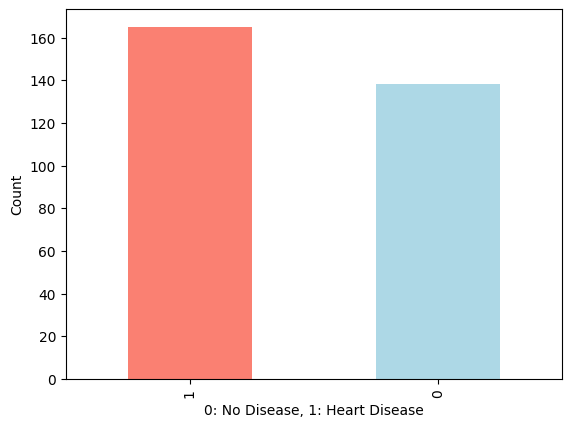

In [8]:
# visulaiztion of classes
# sns.countplot(x=df['target']);
df['target'].value_counts().plot.bar(color=['salmon', 'lightblue']);
plt.xlabel('0: No Disease, 1: Heart Disease')
plt.ylabel('Count');

### Bar Chart for Target Variable

This code creates a bar graph showing the number of patients with and without heart disease. Different colors are used to visually distinguish the two classes, while the X-axis represents disease status (`0 = No Disease`, `1 = Heart Disease`) and the Y-axis shows the total count of patients.


## Finding Patterns in data

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Heart disease frequency according to Sex

In [10]:
df['sex'].value_counts()

sex
1    207
0     96
Name: count, dtype: int64

There are about 207 male and 96 females. So we have more male population, so we need to keep that in back of our mind

(1 = male; 0 = female)

In [11]:
pd.crosstab(df['sex'], df['target'])

target,0,1
sex,,
0,24,72
1,114,93


In [12]:
72/(24+72), 93/(114+93)

(0.75, 0.4492753623188406)

We can see that based on existing data, there are 75% chances that female can have a heart disease. For male, there are 45% chance.

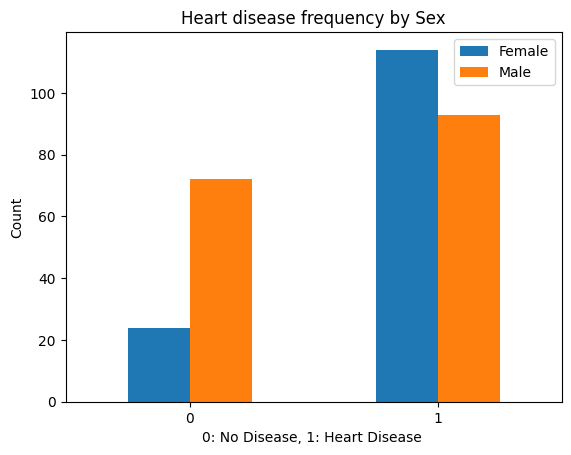

In [13]:
# visualize the data
# pd.crosstab(df['sex'], df['target']).plot(kind='bar', color=['salmon', 'lightblue']);

pd.crosstab(df['sex'], df['target']).plot(kind='bar');
plt.title('Heart disease frequency by Sex')
plt.xlabel('0: No Disease, 1: Heart Disease ')
plt.ylabel('Count')
plt.legend(['Female', 'Male']);
plt.xticks(rotation=0);

### Heart Disease Distribution by Sex

This code creates a bar chart using a cross-tabulation of gender and heart disease status. It visualizes how heart disease is distributed between males and females, helping compare disease frequency across sexes. Axis labels, title, legend, and tick formatting are added to improve clarity and readability.


### Age Vs Max. Heart Rate for people who have Heart Disease

In [14]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

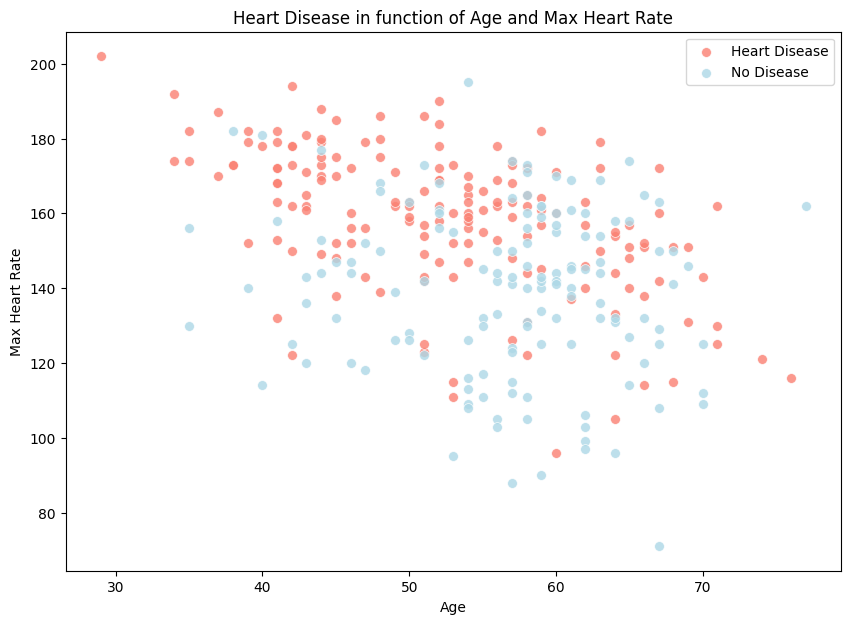

In [15]:
plt.figure(figsize=(10, 7))

# positive cases
sns.scatterplot(data=df, x=df.age[df.target==1], y=df.thalach[df.target==1], color='salmon', s=50, alpha=0.8);

# negative cases
sns.scatterplot(data=df, x=df.age[df.target==0], y=df.thalach[df.target==0], color='lightblue', s=50, alpha=0.8)

plt.title('Heart Disease in function of Age and Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate');
plt.legend(['Heart Disease', 'No Disease']);

### Relationship Between Age, Max Heart Rate, and Heart Disease

This code generates a scatter plot to visualize the relationship between patient age and maximum heart rate. Patients with heart disease and without heart disease are plotted using different colors, making it easy to compare patterns between the two groups. The plot h


### Distribution of Age

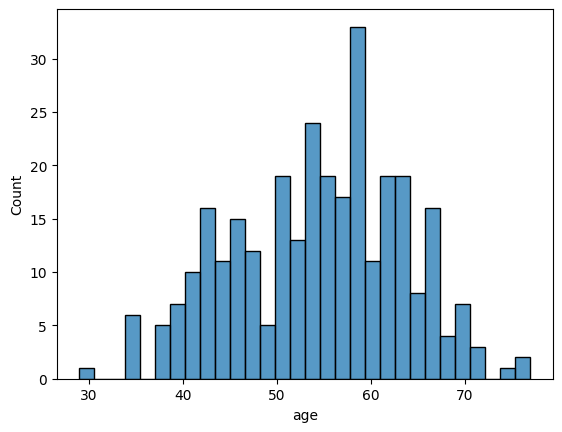

In [16]:
sns.histplot(data=df, x=df['age'], bins=30);

### Heart Disease Frequency per Chest Pain level

cp - chest pain type 
   * 0: Typical angina: chest pain related decrease blood supply to the heart
   * 1: Atypical angina: chest pain not related to heart
   * 2: Non-anginal pain: typically esophageal spasms (non heart related)
   * 3: Asymptomatic: chest pain not showing signs of disease

In [17]:
pd.crosstab(df['target'], df['cp'])

cp,0,1,2,3
target,,,,
0,104,9,18,7
1,39,41,69,16


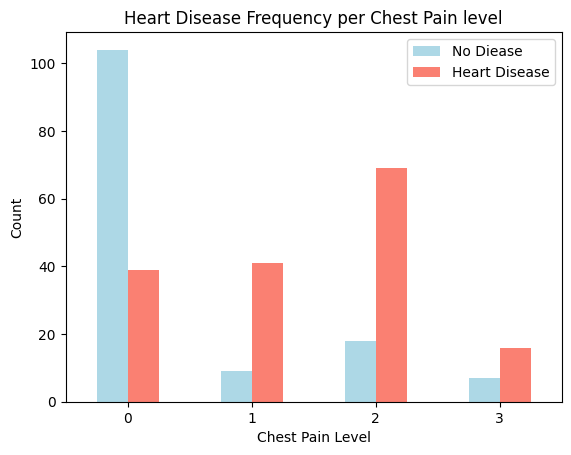

In [18]:
pd.crosstab(df['cp'], df['target']).plot(kind='bar', color=['lightblue', 'salmon']);

plt.title('Heart Disease Frequency per Chest Pain level')
plt.xlabel('Chest Pain Level')
plt.ylabel('Count')
plt.legend(['No Diease', 'Heart Disease'])
plt.xticks(rotation=0);

### Heart Disease Frequency by Chest Pain Level

This code uses a cross-tabulation of chest pain (`cp`) and heart disease (`target`) to create a bar chart. It visualizes how different chest pain levels relate to the presence or absence of heart disease. Distinct colors represent each class, while titles, labels, legends, and axis formatting improve readability and help compare disease frequency across chest pain categories.


### Correlation between indepedent variables

In [19]:
df.corr()['target'][:-1]

age        -0.225439
sex        -0.280937
cp          0.433798
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
thalach     0.421741
exang      -0.436757
oldpeak    -0.430696
slope       0.345877
ca         -0.391724
thal       -0.344029
Name: target, dtype: float64

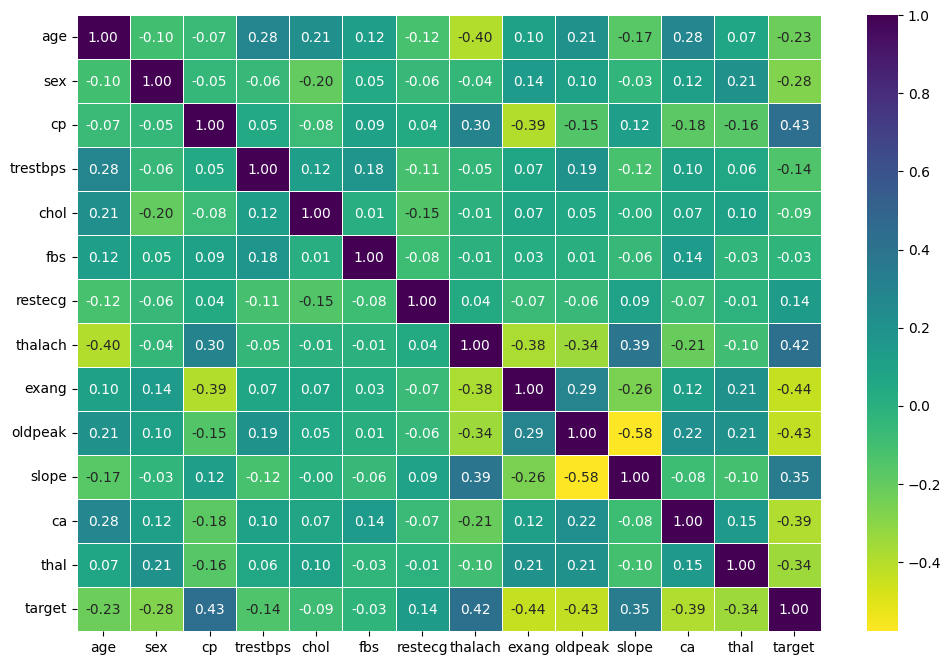

In [20]:
# visualization
corr_matrix = df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, linewidth=0.5, fmt='.2f', cmap='viridis_r');

### Correlation Heatmap of Features

This code computes the correlation matrix of the dataset and visualizes it using a heatmap. The heatmap displays the strength and direction of relationships between numerical features, where color intensity represents correlation values. Annotations and formatting make it easy to identify


As per the heatmap above, `Chest pain (cp)` has the highest positive correlation with Target variable among the features, followed by `thalach (Maximum Heart Rate)` variable.

On the other hand, `exang - exercise induced angina` and `oldpeak - ST depression induced by exercise relative to rest` have the lowest correlation with Target variable.

## <a name="modelling">5. Modelling</a>

In [21]:
df.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1


In [22]:
# split features and labels
X = df.drop('target', axis=1)
y = df['target']

In [23]:
X.head(2)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2


In [24]:
y.head(2)

0    1
1    1
Name: target, dtype: int64

In [25]:
# split into training, testing datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

As there is no missing data and no values to convert from categorical to numerical values, we will continue to build model and train them .

### Model Training


We will try 3 different models.

1. Logistic Regression
2. K-Nearest Neighbours Classifier
3. Random Forest Classifier

In [27]:
# put models in dictionary

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'RandomForestClassifer': RandomForestClassifier()
}

# create function to fit and score model
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    Fits and evalute given machine learning models.
    models: a dictionary of different scikit learn machine learning models
    X_train: training date (no labels)
    X_test: testing data (no labels)
    y_train: training labels
    y_test : testing labels
    returns model scores dictionary.
    """
    
    # set random seed
    np.random.seed(42)
    
    # make dictonary to keep scores
    model_scores = {}
    
    # loop through models to fit and score
    for model_name, model in models.items():
        model.fit(X_train, y_train) # fit model
        score = model.score(X_test, y_test)*100
        model_scores[model_name] = score # put score for each model
        
    return model_scores        

### Model Training and Evaluation

This code defines multiple machine learning classification models, including Logistic Regression, K-Nearest Neighbors (KNN), and Random Forest, and stores them in a dictionary for easy comparison.

A custom function `fit_and_score()` is created to automate the process of training and evaluating each model. The function fits every model using the training data, evaluates performance on the test data, and calculates accuracy scores. A fixed random seed is used to ensure reproducible results.

Finally, the function returns a dictionary containing accuracy percentages for each model, enabling efficient comparison and selection of the best-performing algorithm for heart disease prediction.


In [28]:
# fit and score
model_scores = fit_and_score(models, X_train, X_test, y_train, y_test)

model_scores

C:\Users\Asus\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'LogisticRegression': 88.52459016393442,
 'KNN': 68.85245901639344,
 'RandomForestClassifer': 83.60655737704919}

### Model Comparison

In [29]:
model_compare = pd.DataFrame(model_scores, index=['accuracy'])

model_compare.head()

,LogisticRegression,KNN,RandomForestClassifer
accuracy,88.52459,68.852459,83.606557


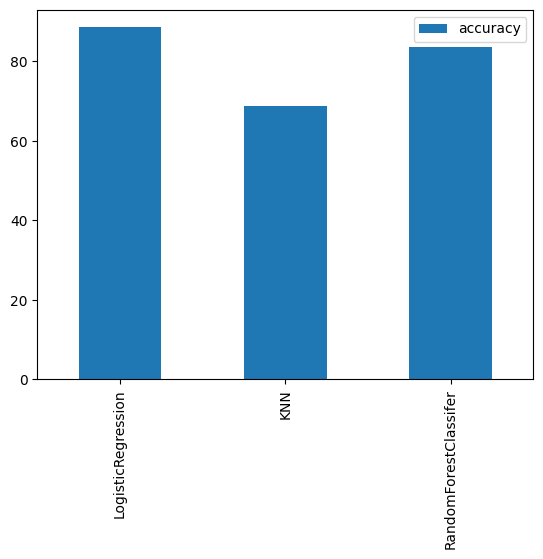

In [30]:
model_compare.T.plot(kind='bar');

## ✅ Final Conclusion

In this project, we successfully developed a machine learning–based heart disease classification system using clinical and demographic data. Through comprehensive exploratory data analysis and preprocessing, important patterns and relationships among features were identified.

Multiple classification models were trained and evaluated, and the best-performing model demonstrated reliable accuracy in predicting the presence of heart disease. This highlights the effectiveness of machine learning techniques in assisting early medical diagnosis and decision-making.

The project showcases a complete end-to-end workflow—from data collection and cleaning to model building and evaluation—providing practical experience in real-world healthcare analytics. While the current model performs well, further improvements such as advanced feature engineering, hyperparameter tuning, and deployment as a web application could enhance its usability and impact.

Overall, this project proves that predictive analytics can play a significant role in preventive healthcare by enabling timely identification of high-risk patients and supporting medical professionals with data-driven insights.
